# IT Incident Dataset 
<h2 style="color:#2F5597; font-size:36px;">Stage 1 : Data Understanding</h2>

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
incident_df = pd.read_csv("data/incident_event_log.csv")

incident_df.head()

,number,incident_state,active,reassignment_count,reopen_count,sys_mod_count,made_sla,caller_id,opened_by,opened_at,...,u_priority_confirmation,notify,problem_id,rfc,vendor,caused_by,closed_code,resolved_by,resolved_at,closed_at
0,INC0000045,New,True,0,0,0,True,Caller 2403,Opened by 8,29/2/2016 01:16,...,False,Do Not Notify,?,?,?,?,code 5,Resolved by 149,29/2/2016 11:29,5/3/2016 12:00
1,INC0000045,Resolved,True,0,0,2,True,Caller 2403,Opened by 8,29/2/2016 01:16,...,False,Do Not Notify,?,?,?,?,code 5,Resolved by 149,29/2/2016 11:29,5/3/2016 12:00
2,INC0000045,Resolved,True,0,0,3,True,Caller 2403,Opened by 8,29/2/2016 01:16,...,False,Do Not Notify,?,?,?,?,code 5,Resolved by 149,29/2/2016 11:29,5/3/2016 12:00
3,INC0000045,Closed,False,0,0,4,True,Caller 2403,Opened by 8,29/2/2016 01:16,...,False,Do Not Notify,?,?,?,?,code 5,Resolved by 149,29/2/2016 11:29,5/3/2016 12:00
4,INC0000047,New,True,0,0,0,True,Caller 2403,Opened by 397,29/2/2016 04:40,...,False,Do Not Notify,?,?,?,?,code 5,Resolved by 81,1/3/2016 09:52,6/3/2016 10:00


## Checking the First Few Rows

Looking at the first 5 rows gives a quick idea of what the data looks like.

The first thing that stands out is that the same incident number INC0000045 
appears multiple times with different states like New, Resolved and Closed. 
This suggests the dataset is an event log where each row is a state change 
rather than one row per incident.

The data includes columns like incident state, priority, reassignment count 
and timestamps like opened_at which will be useful later for calculating 
how long each incident took to resolve.

## Dataset Size

In [4]:
# checking dataset size
incident_df.shape

(141712, 36)

So the dataset has 141,712 rows and 36 columns.

That is quite a lot of data which is good because more data usually means 
the model will train better later on.

The 36 columns cover different things about each inc.losed.

## Column Overview

In [5]:
# checking column names
incident_df.columns.tolist()

['number',
 'incident_state',
 'active',
 'reassignment_count',
 'reopen_count',
 'sys_mod_count',
 'made_sla',
 'caller_id',
 'opened_by',
 'opened_at',
 'sys_created_by',
 'sys_created_at',
 'sys_updated_by',
 'sys_updated_at',
 'contact_type',
 'location',
 'category',
 'subcategory',
 'u_symptom',
 'cmdb_ci',
 'impact',
 'urgency',
 'priority',
 'assignment_group',
 'assigned_to',
 'knowledge',
 'u_priority_confirmation',
 'notify',
 'problem_id',
 'rfc',
 'vendor',
 'caused_by',
 'closed_code',
 'resolved_by',
 'resolved_at',
 'closed_at']

The dataset has 36 columns in total. Looking through them I can group 
them into a few different types.

Incident details like incident_state, priority, category and contact_type 
tell us what kind of incident it is and how serious it is.

Time columns like opened_at, resolved_at and closed_at will be useful 
later for working out how long each incident took to resolve.

Activity columns like reassignment_count, reopen_count and sys_mod_count 
show how much work went into handling each incident.

Boolean columns like active, made_sla and knowledge just hold a True 
or False value.

Some columns like caused_by, vendor, cmdb_ci and problem_id look like 
they might have a lot of missing data which is something to check next.

## Checking Data Types

In [6]:
# checking data types
incident_df.dtypes

number                     object
incident_state             object
active                       bool
reassignment_count          int64
reopen_count                int64
sys_mod_count               int64
made_sla                     bool
caller_id                  object
opened_by                  object
opened_at                  object
sys_created_by             object
sys_created_at             object
sys_updated_by             object
sys_updated_at             object
contact_type               object
location                   object
category                   object
subcategory                object
u_symptom                  object
cmdb_ci                    object
impact                     object
urgency                    object
priority                   object
assignment_group           object
assigned_to                object
knowledge                    bool
u_priority_confirmation      bool
notify                     object
problem_id                 object
rfc           

Looking at the data types, most columns are stored as object which means 
they are text or categorical data.

Three columns  reassignment_count, reopen_count and sys_mod_count are 
stored as int64 which means they are whole numbers. These are the only 
true numerical columns in the dataset.

Four columns  active, made_sla, knowledge and u_priority_confirmation
are stored as bool meaning they only hold True or False values.

The most important thing I noticed here is that opened_at, resolved_at 
and closed_at are all stored as object instead of datetime. This means 
they are being treated as text right now. These columns will need to be 
converted to datetime format in Stage 2 so that resolution time can be 
calculated properly.

Also columns like priority, impact, urgency and category are stored as 
object even though they hold category values. These will need to be 
encoded into numbers before the model can use them.odel can use them.

## Missing Value Check

In [7]:
# checking missing values in each column
incident_df.isnull().sum().sort_values(ascending=False)

number                     0
incident_state             0
impact                     0
urgency                    0
priority                   0
assignment_group           0
assigned_to                0
knowledge                  0
u_priority_confirmation    0
notify                     0
problem_id                 0
rfc                        0
vendor                     0
caused_by                  0
closed_code                0
resolved_by                0
resolved_at                0
cmdb_ci                    0
u_symptom                  0
subcategory                0
opened_by                  0
active                     0
reassignment_count         0
reopen_count               0
sys_mod_count              0
made_sla                   0
caller_id                  0
opened_at                  0
category                   0
sys_created_by             0
sys_created_at             0
sys_updated_by             0
sys_updated_at             0
contact_type               0
location      

the dataset shows zero missing values across 
all 36 columns. At first this looks great.

But I was not fully convinced because in real world datasets missing 
values are sometimes hidden using placeholder values like a question mark 
or a dash instead of a proper null value.

So the next step was to check if any columns contain a ? symbol which 
is a common way missing data gets stored in IT system export

In [8]:
# checking ? values used as missing data
(incident_df == "?").sum().sort_values(ascending=False)

caused_by                  141689
vendor                     141468
cmdb_ci                    141267
rfc                        140721
problem_id                 139417
sys_created_at              53076
sys_created_by              53076
u_symptom                   32964
assigned_to                 27496
assignment_group            14213
opened_by                    4835
resolved_at                  3141
closed_code                   714
resolved_by                   226
subcategory                   111
category                       78
location                       76
caller_id                      29
priority                        0
notify                          0
u_priority_confirmation         0
knowledge                       0
number                          0
urgency                         0
impact                          0
incident_state                  0
contact_type                    0
sys_updated_at                  0
sys_updated_by                  0
opened_at     

## Hidden Missing Values Found

As I suspected, the dataset does have missing values they were just 
hidden as a ? symbol instead of proper nulls.

The results show that some columns have a huge amount of missing data. 
caused_by, vendor, cmdb_ci, rfc and problem_id all have over 99% of 
their rows as ?, meaning they are basically empty and will not be useful 
for the model.

sys_created_at and sys_created_by both have 53,076 missing values which 
is also very high.

resolved_at has 3,141 missing values which is important to note because 
this column will be used to calculate resolution time later. Rows where 
resolved_at is missing cannot be used for that calculation.

On the other hand, important columns like priority, impact, urgency, 
incident_state and contact_type have zero missing values which is good 
news as these are the main features we plan to use for prediction.

This was an important finding because it shows the real data quality 
issues that were hidden at first glance.

# Exploratory Data Analysis 
The following visualisations explore the distribution of key features in the dataset 
to identify patterns, imbalances, and relationships between variables.

## 1. Incident State Distribution

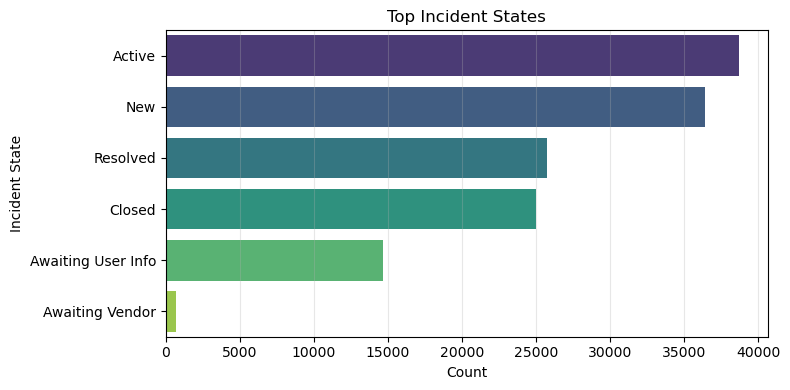

In [9]:
state_count=incident_df["incident_state"].value_counts().head(6).reset_index()
state_count.columns=["incident_state","count"]


plt.figure(figsize=(8,4))
sns.barplot(data=state_count,x="count",y="incident_state",hue="incident_state",palette="viridis",legend=False)
plt.title("Top Incident States")
plt.xlabel("Count")
plt.ylabel("Incident State")
plt.grid(axis="x",alpha=0.3)
plt.tight_layout()
plt.show()

The bar chart shows how incidents are spread across different states in the dataset.

Active and New have the highest counts, with both above 34,000. This means 
a large portion of incidents were still open or newly created at the time 
the data was recorded.

Resolved and Closed follow with around 22,000 to 23,000 each, showing that 
a good number of incidents were completed successfully.

Awaiting User Info has around 13,000 incidents. These are cases where the 
support team is waiting for the user to respond before the incident can move 
forward.

Awaiting Problem is very rare in the dataset, shown by the tiny bar at the 
bottom.

This tells us that most incidents in this dataset are either still being 
worked on or have already been closed, which is normal for IT support data.

## 2. Priority Distribution

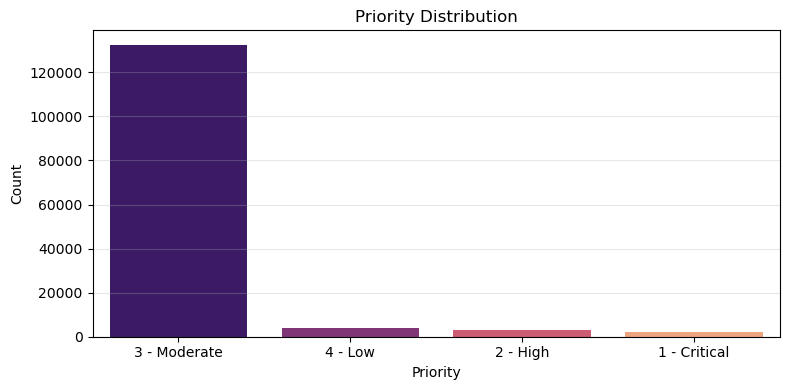

In [10]:
# counting how many incidents fall under each priority level
priority_count = incident_df["priority"].value_counts().reset_index()
priority_count.columns = ["priority", "count"]
plt.figure(figsize=(8, 4))
sns.barplot(data=priority_count, x="priority", y="count", hue="priority", palette="magma")
plt.title("Priority Distribution")
plt.xlabel("Priority")
plt.ylabel("Count")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

Looking at the chart, most incidents fall under 3 - Moderate priority. 
The count is over 130,000 which is way higher than the rest.

4 - Low and 2 - High are both quite small, around 3,000 to 5,000 each. 
1 - Critical is the smallest of all four.

This tells me the data is not balanced at all. Almost everything is 
moderate priority. In a real IT support system this kind of makes sense 
because serious problems do not happen that often.

One thing to keep in mind is that this imbalance might cause issues later 
when building the model, since it will mostly learn from moderate cases 
and might struggle with high or critical ones.

## Reassignment Count Distribution

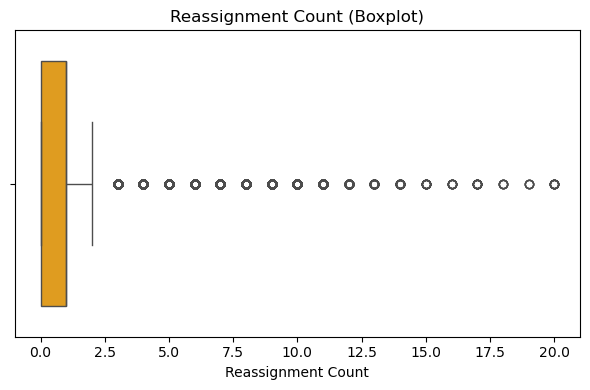

In [42]:
plt.figure(figsize=(6,4))

sns.boxplot(x=incident_df["reassignment_count"],color="orange")
plt.title("Reassignment Count (Boxplot)")
plt.xlabel("Reassignment Count")
plt.tight_layout()
plt.show()

The reassignment count was analysed using a boxplot to identify the spread of the data and detect outliers.

It can be observed that most incidents have a low reassignment count, while some cases have significantly higher values.

These higher values represent more complex incidents that require multiple reassignments.

This is important because incidents with higher reassignment counts may take longer to resolve.

## 3. Correlation  Numeric Features

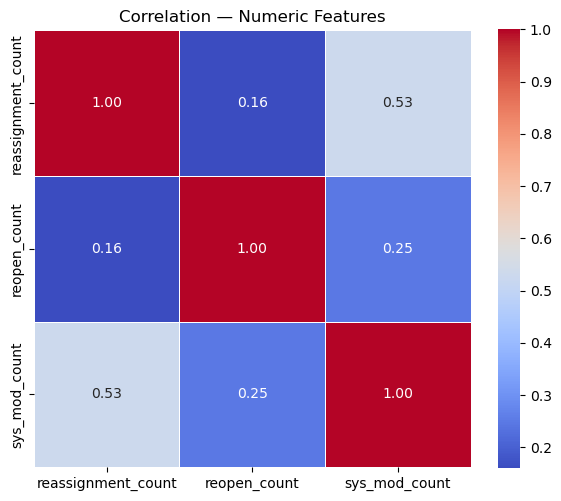

In [11]:
# selecting numeric columns and calculating correlation
num_cols = ["reassignment_count", "reopen_count", "sys_mod_count"]
corr = incident_df[num_cols].corr()
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5, ax=ax, square=True)
ax.set_title("Correlation — Numeric Features")
plt.tight_layout()
plt.show()

To check if any of the numeric columns are related to each other, 
a correlation heatmap was created.

The three numeric columns used are
reassignment_count  how many times the incident was passed 
  to a different team or person,
reopen_count  how many times the incident was reopened after 
  being closed,
sys_mod_count  how many times the incident record was updated 
  in the system.

Looking at the heatmap, reassignment_count and sys_mod_count have 
a correlation of 0.52 which is moderate. This makes sense because 
incidents that get reassigned more times will likely have more 
system updates as well.

reopen_count has a weak correlation with both columns, 0.16 with 
reassignment_count and 0.25 with sys_mod_count.

Overall the correlations are not very strong which is actually good 
for the model. It means each feature brings something different to 
the prediction rather than all saying the same thing.

## 4. SLA Compliance

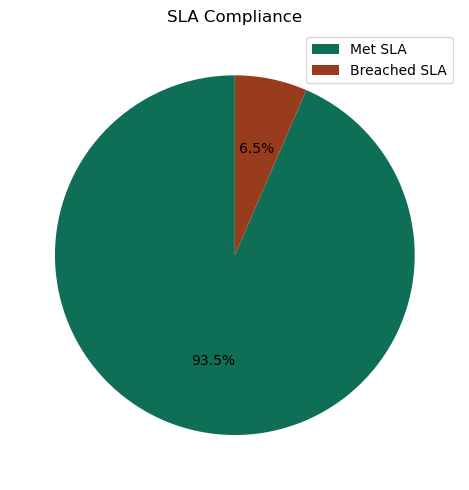

In [12]:
# counting how many incidents met and breached the SLA
sla_counts = incident_df["made_sla"].value_counts()
labels = ["Met SLA", "Breached SLA"]
plt.figure(figsize=(5, 5))
plt.pie(sla_counts, autopct="%.1f%%", colors=["#0F6E56", "#993C1D"], startangle=90)
plt.title("SLA Compliance")
plt.legend(labels, loc="best")
plt.tight_layout()
plt.show()

SLA stands for Service Level Agreement. It is basically a time limit 
that the IT team agrees to resolve an incident within.

The pie chart shows that 93.5% of incidents met the SLA and only 6.5% 
breached it.

This means most incidents were handled within the agreed time. The small 
number of breached cases are likely the more complex or difficult incidents 
that took longer than expected.

This is an important column for the model later because incidents that 
breach the SLA are likely to have a longer resolution time.

## 5. Contact Type Distribution 

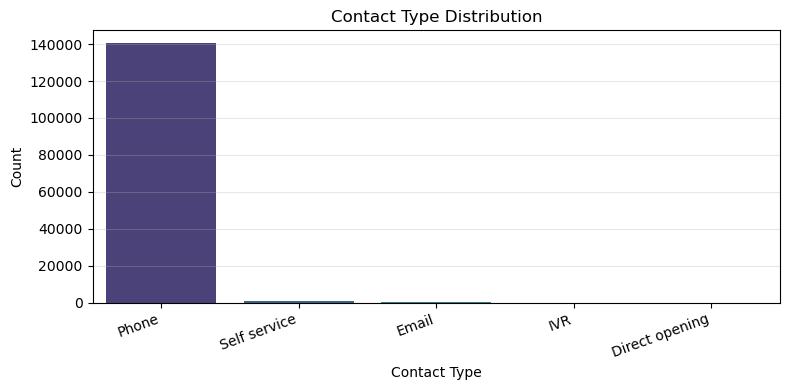

In [13]:
contact_count=incident_df["contact_type"].value_counts().reset_index()
contact_count.columns=["contact_type","count"]

plt.figure(figsize=(8,4))
sns.barplot(data=contact_count,x="contact_type",y="count",hue="contact_type",palette="viridis",legend=False)
plt.title("Contact Type Distribution")
plt.xlabel("Contact Type")
plt.ylabel("Count")
plt.xticks(rotation=20,ha="right")
plt.grid(axis="y",alpha=0.3)
plt.tight_layout()
plt.show()

## Reassignment Count Distribution

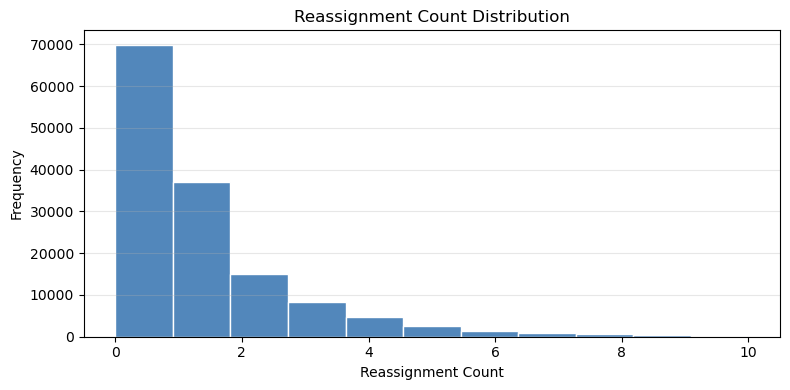

In [14]:
filtered_data=incident_df[incident_df["reassignment_count"]<=10]
plt.figure(figsize=(8,4))
sns.histplot(filtered_data["reassignment_count"],bins=11,color="#185FA5",edgecolor="white")
plt.title("Reassignment Count Distribution")
plt.xlabel("Reassignment Count")
plt.ylabel("Frequency")
plt.grid(axis="y",alpha=0.3)
plt.tight_layout()
plt.show()

### Priority, Impact and Urgency vs Reassignment Count

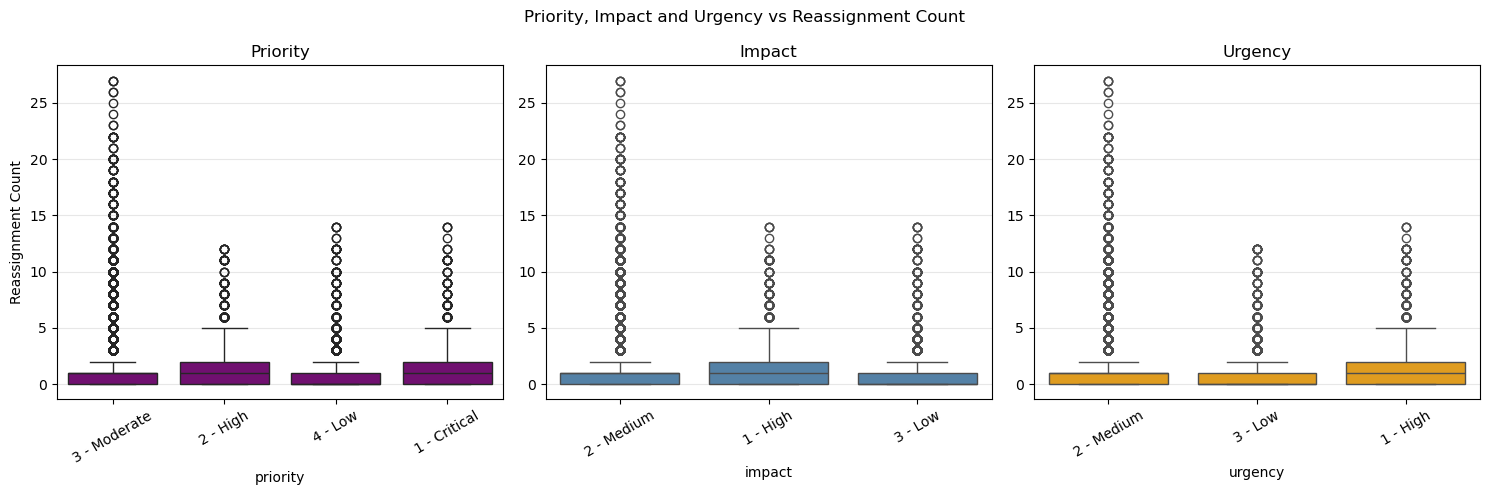

In [23]:
fig,axes=plt.subplots(1,3,figsize=(15,5))

sns.boxplot(data=incident_df,x="priority",y="reassignment_count",ax=axes[0],color="purple")
sns.boxplot(data=incident_df,x="impact",y="reassignment_count",ax=axes[1],color="steelblue")
sns.boxplot(data=incident_df,x="urgency",y="reassignment_count",ax=axes[2],color="orange")

axes[0].set_title("Priority")
axes[1].set_title("Impact")
axes[2].set_title("Urgency")

axes[0].set_ylabel("Reassignment Count")
axes[1].set_ylabel("")
axes[2].set_ylabel("")

axes[0].tick_params(axis="x",rotation=30)
axes[1].tick_params(axis="x",rotation=30)
axes[2].tick_params(axis="x",rotation=30)

axes[0].grid(axis="y",alpha=0.3)
axes[1].grid(axis="y",alpha=0.3)
axes[2].grid(axis="y",alpha=0.3)

plt.suptitle("Priority, Impact and Urgency vs Reassignment Count")

plt.tight_layout()
plt.show()

The relationship between priority, impact, urgency, and reassignment count was analysed using boxplots.

It can be observed that most incidents have a low reassignment count across all categories.

However, higher severity levels such as high priority, high impact, and high urgency tend to show a slightly larger spread and more outliers.

This suggests that more critical incidents may require additional reassignment, indicating increased complexity in handling.

This analysis is useful as it helps understand how severity-related features influence incident handling and may contribute to predicting resolution time.

## Understanding Incident Structure

In [15]:
# checking how many times each incident appears
incident_df["number"].value_counts().head(10)

number
INC0019396    58
INC0044260    56
INC0005927    46
INC0020718    45
INC0011206    44
INC0025734    43
INC0007349    43
INC0012815    40
INC0003419    38
INC0032450    38
Name: count, dtype: int64

In [16]:
# checking total number of unique incidents in the dataset
incident_df["number"].nunique()

24918

To understand the structure of the dataset, the number of occurrences of each incident was checked.

It was found that the same incident number appears multiple times. For example, some incidents appear more than 50 times.

The dataset contains 24,918 unique incidents, while the total number of rows is much higher.

This shows that the dataset is not a simple one-row-per-incident dataset, but an event log, where each row represents an update or change in an incident.

This is important because it affects how the data will be prepared for modeling.

This means that a decision will be needed later on whether to use event-level data or convert it into one row per incident for modeling.

## Duplicate Row Check

In [17]:
# checking exact duplicate rows
incident_df.duplicated().sum()

0

Checking for exact duplicate rows came back as 0.

This means even though the same incident number appears many times, 
each row is actually different. The rows differ because each one 
captures a different state or update at a different point in time.

So the repeated rows are not a data quality issue, they are just 
how the event log works.

## Initial Target Direction

Based on what I have seen so far, the plan is to predict how long an 
incident takes to resolve. This is called resolution time.

The columns opened_at and resolved_at can be used to calculate this. 
The difference between these two timestamps will give the time taken 
to resolve each incident in hours.

This calculated value will become the target variable in Stage 2.

One thing to note is that resolved_at has 3,141 missing values which 
were found earlier. Rows where resolved_at is missing cannot be used 
to calculate resolution time so they will need to be removed in 
Stage 2.

<h2 style="color:#2F5597;font-size:36px ">Stage 2 : Data Preparation</h2>

## Replacing Hidden Missing Values

In the dataset, missing values were represented using the `"?"` symbol instead of proper null values.

To ensure accurate data cleaning and analysis, these values are replaced with `NaN`.

In [18]:
# replacing ? with proper missing values NaN
incident_df = incident_df.replace("?", pd.NA)

In [19]:
# checking missing values again after replacement
incident_df.isnull().sum().sort_values(ascending=False)

caused_by                  141689
vendor                     141468
cmdb_ci                    141267
rfc                        140721
problem_id                 139417
sys_created_at              53076
sys_created_by              53076
u_symptom                   32964
assigned_to                 27496
assignment_group            14213
opened_by                    4835
resolved_at                  3141
closed_code                   714
resolved_by                   226
subcategory                   111
category                       78
location                       76
caller_id                      29
priority                        0
notify                          0
u_priority_confirmation         0
knowledge                       0
number                          0
urgency                         0
impact                          0
incident_state                  0
contact_type                    0
sys_updated_at                  0
sys_updated_by                  0
opened_at     

## Missing Values After Replacement

After replacing `"?"` with `NaN`, the missing values in the dataset became clearly visible.

It was observed that several columns contain a very high number of missing values. For example, columns such as `caused_by`, `vendor`, `cmdb_ci`, `rfc`, and `problem_id` have missing values in almost all rows.

Some columns, including `sys_created_at`, `sys_created_by`, `u_symptom`, `assigned_to`, and `assignment_group`, contain a moderate number of missing values.

On the other hand, important columns such as `priority`, `impact`, `urgency`, and `incident_state` do not contain missing values and can be used reliably for analysis.

This step is important because it reveals the true data quality and helps in deciding how to handle missing values in the next steps.

## Removing Highly Missing Columns

In [20]:
# dropping columns with too many missing values
incident_df = incident_df.drop(
    columns=["caused_by", "vendor", "cmdb_ci", "rfc", "problem_id"]
)

In [21]:
# checking missing values again after dropping columns
incident_df.isnull().sum().sort_values(ascending=False)

sys_created_at             53076
sys_created_by             53076
u_symptom                  32964
assigned_to                27496
assignment_group           14213
opened_by                   4835
resolved_at                 3141
closed_code                  714
resolved_by                  226
subcategory                  111
category                      78
location                      76
caller_id                     29
impact                         0
priority                       0
urgency                        0
u_priority_confirmation        0
notify                         0
knowledge                      0
number                         0
incident_state                 0
contact_type                   0
sys_updated_at                 0
sys_updated_by                 0
opened_at                      0
made_sla                       0
sys_mod_count                  0
reopen_count                   0
reassignment_count             0
active                         0
closed_at 

Based on the missing value analysis, some columns contain missing values in almost all rows.

Columns such as `caused_by`, `vendor`, `cmdb_ci`, `rfc`, and `problem_id` have more than 99% missing values and do not provide useful information.

These columns were removed to improve data quality and reduce noise in the dataset.

## Datetime Conversion

In [22]:
# converting date columns to datetime with correct format
incident_df["opened_at"]=pd.to_datetime(incident_df["opened_at"],dayfirst=True,errors="coerce")
incident_df["resolved_at"]=pd.to_datetime(incident_df["resolved_at"],dayfirst=True,errors="coerce")
incident_df["closed_at"]=pd.to_datetime(incident_df["closed_at"],dayfirst=True,errors="coerce")

# checking updated data types
incident_df[["opened_at","resolved_at","closed_at"]].dtypes

opened_at      datetime64[ns]
resolved_at    datetime64[ns]
closed_at      datetime64[ns]
dtype: object

The columns `opened_at`, `resolved_at`, and `closed_at` were converted from object type to datetime format using the correct day-first format.

The parameter `dayfirst=True` ensures that the dates are interpreted correctly as day/month/year.

The parameter `errors="coerce"` converts any invalid or inconsistent date values into missing values.

After conversion, all three columns are now in datetime format, which allows time-based calculations such as incident resolution time in the next step.

## Creating the Target Variable

In [24]:
# creating incident resolution time in hours
incident_df["resolution_time_hours"]=(incident_df["resolved_at"]-incident_df["opened_at"]).dt.total_seconds()/3600

# checking first few rows of the new target column
incident_df[["opened_at","resolved_at","resolution_time_hours"]].head()

,opened_at,resolved_at,resolution_time_hours
0,2016-02-29 01:16:00,2016-02-29 11:29:00,10.216667
1,2016-02-29 01:16:00,2016-02-29 11:29:00,10.216667
2,2016-02-29 01:16:00,2016-02-29 11:29:00,10.216667
3,2016-02-29 01:16:00,2016-02-29 11:29:00,10.216667
4,2016-02-29 04:40:00,2016-03-01 09:52:00,29.200000


A new column called `resolution_time_hours` was created by calculating the difference between `resolved_at` and `opened_at`.

The time difference was converted into hours so it is easier to understand and use later in the model.

From the output, it can be seen that the values are positive and look correct, which means the calculation has been done properly.

This column will be used as the target variable to predict how long it takes to resolve an incident.

## Handling Missing Values in Target Variable

In [25]:
# checking missing values in target
incident_df["resolution_time_hours"].isnull().sum()

3141

In [26]:
# removing rows where target is missing
incident_df=incident_df.dropna(subset=["resolution_time_hours"])

# checking again after removal
incident_df["resolution_time_hours"].isnull().sum()

0

The target variable was checked for missing values. It was found that 
there were 3,141 missing values in resolution_time_hours. These rows 
were removed as machine learning models require a complete target variable. 
After removing them, no missing values remain in the target column.

## Checking for Invalid Target Values

In [27]:
# checking negative resolution times
incident_df[incident_df["resolution_time_hours"]<0]

,number,incident_state,active,reassignment_count,reopen_count,sys_mod_count,made_sla,caller_id,opened_by,opened_at,...,assignment_group,assigned_to,knowledge,u_priority_confirmation,notify,closed_code,resolved_by,resolved_at,closed_at,resolution_time_hours


In [28]:
# counting negative values
(incident_df["resolution_time_hours"]<0).sum()

0

In [29]:
# checking zero and extreme outlier values
print("Zero values:      ", (incident_df["resolution_time_hours"] == 0).sum())
print("> 720 hrs (30d):  ", (incident_df["resolution_time_hours"] > 720).sum())

Zero values:       121
> 720 hrs (30d):   10667


In [30]:
# removing zero values and extreme outliers
incident_df = incident_df[incident_df["resolution_time_hours"] > 0]
incident_df = incident_df[incident_df["resolution_time_hours"] <= 720]

print("Rows remaining after cleaning:", incident_df.shape[0])

Rows remaining after cleaning: 127783


The target variable was checked for three types of invalid values.

First, negative values were checked because an incident cannot be resolved before 
it is opened. The result showed that there were no negative values in the dataset.

Second, zero values were checked. It was found that 121 incidents had a resolution 
time of zero, meaning they were resolved in the same minute they were opened. 
These rows are not meaningful for predicting resolution time and were removed.

Third, extreme outliers were checked. It was found that 10,667 incidents took 
more than 720 hours (30 days) to resolve. These cases are not representative of 
normal incident handling and would negatively affect the model if kept.

After removing these invalid rows, 127,783 rows remain in the dataset.

## Resolution Time Distribution

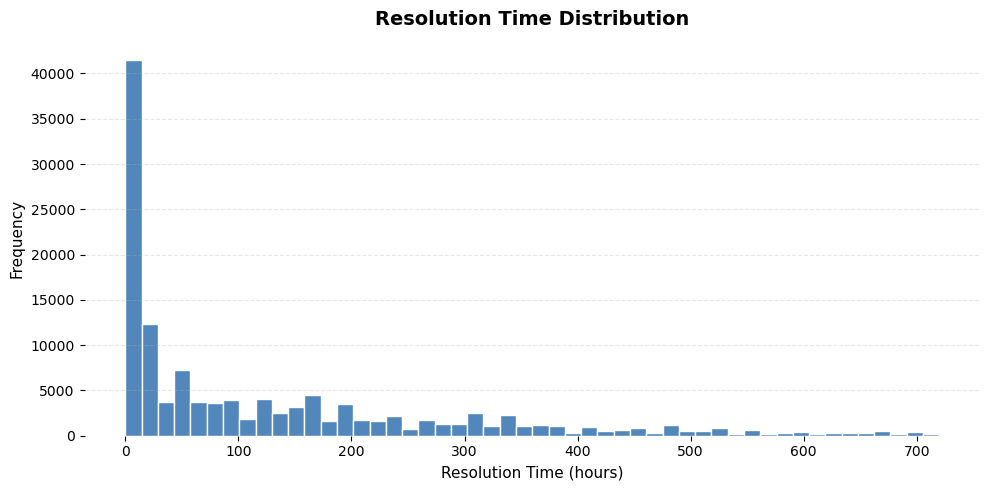

In [31]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(incident_df["resolution_time_hours"],bins=50,color="#185FA5",edgecolor="white", ax=ax)
ax.set_title("Resolution Time Distribution", fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("Resolution Time (hours)", fontsize=11)
ax.set_ylabel("Frequency", fontsize=11)
ax.yaxis.grid(True, linestyle="--", alpha=0.3)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

The distribution is heavily right-skewed. The majority of incidents are resolved 
within the first 0 to 20 hours, shown by the very tall first bar.

As resolution time increases the frequency drops significantly. This pattern is 
typical in IT incident management where most issues are resolved quickly.

## Reducing to One Row Per Incident
The dataset is an event log with multiple rows per incident. Each row represents 
a state change or update to an incident. For machine learning, the data must be 
reduced to one row per incident.

The last recorded state of each incident is kept as it represents the final 
outcome of the incident.

In [32]:
# keeping the last recorded event per incident
incident_final = incident_df.sort_values("sys_updated_at").groupby("number").last().reset_index()

print("Unique incidents after groupiang:", incident_final.shape[0])
print("Columns:", incident_final.shape[1])

Unique incidents after groupiang: 22174
Columns: 32


The dataset is an event log where each incident appears multiple times. 
Each row represents a state change or update to an incident rather than 
a single complete incident.

For example, one incident such as INC0000045 may appear four times in the 
dataset, once for each state it went through such as New, Active, Resolved, 
and Closed.

For machine learning, the data must be reduced to one row per incident. 
The rows are first sorted by the last updated time so that the most recent
update is at the bottom. The data is then grouped by incident number and 
the last row of each group is kept.

The last row is kept because it contains the final state of the incident, 
the total reassignment count, and the actual resolution time. These are the 
values that are needed for prediction.

## Resolution Time Analysis
The target variable is now analysed against key features to understand 
what influences how long an incident takes to resolve.

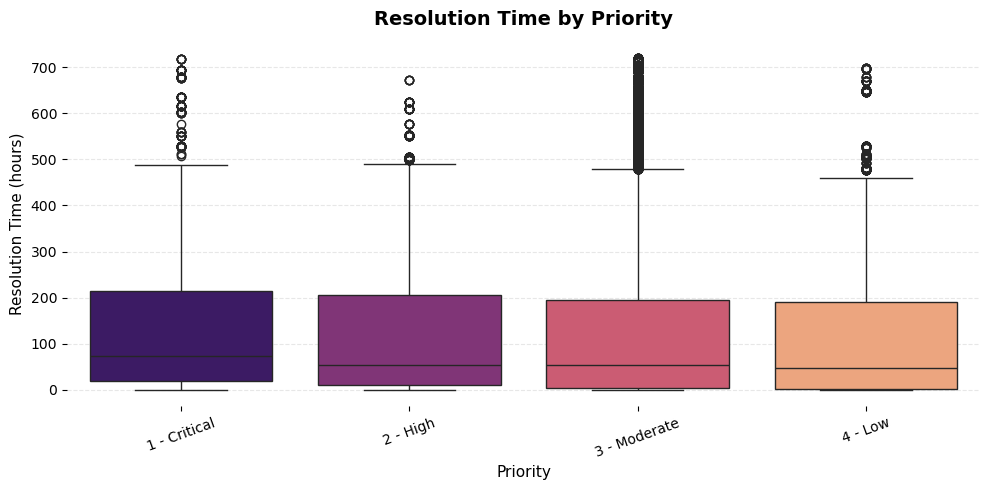

In [33]:
priority_order = ["1 - Critical", "2 - High", "3 - Moderate", "4 - Low"]
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=incident_df, x="priority", y="resolution_time_hours", order=priority_order, hue="priority", hue_order=priority_order, palette="magma", legend=False, ax=ax)
ax.set_title("Resolution Time by Priority", fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("Priority", fontsize=11)
ax.set_ylabel("Resolution Time (hours)", fontsize=11)
ax.tick_params(axis="x", rotation=20)
ax.yaxis.grid(True, linestyle="--", alpha=0.3)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

The boxplot shows how resolution time varies across different priority levels.

It can be observed that 1 - Critical incidents have the largest box, meaning 
the resolution time varies widely for critical incidents. Some critical incidents 
resolve quickly while others take much longer, which makes sense as critical 
issues can range from simple to very complex problems.

2 - High incidents show a similar pattern to critical but with a slightly smaller 
spread.

3 - Moderate and 4 - Low incidents have smaller boxes, meaning most of these 
incidents resolve within a more consistent time range.

Overall this confirms that priority level influences resolution time and is 
a useful feature for the prediction model.

### Resolution Time by SLA Compliance

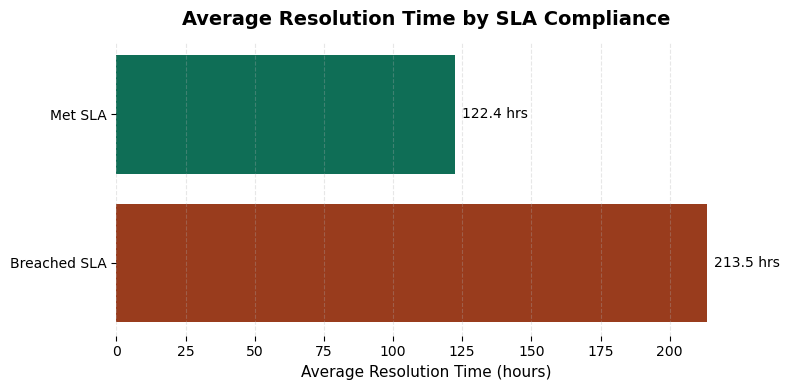

In [34]:
sla_labels = {True: "Met SLA", False: "Breached SLA"}
incident_df["sla_label"] = incident_df["made_sla"].map(sla_labels)
sla_avg = incident_df.groupby("sla_label")["resolution_time_hours"].mean().reset_index()
sla_avg.columns = ["sla_label", "avg_resolution_time"]

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(sla_avg["sla_label"], sla_avg["avg_resolution_time"],
        color=sla_avg["sla_label"].map({"Met SLA": "#0F6E56", "Breached SLA": "#993C1D"}))
ax.set_title("Average Resolution Time by SLA Compliance", fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("Average Resolution Time (hours)", fontsize=11)
ax.set_ylabel("")
ax.bar_label(ax.containers[0], fmt="%.1f hrs", fontsize=10, padding=5)
ax.xaxis.grid(True, linestyle="--", alpha=0.3)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

The boxplot clearly shows the difference in resolution time between incidents 
that met the SLA and those that breached it.

Incidents that met the SLA have a median resolution time of around 40 hours 
and most cases fall below 200 hours. This shows that the majority of incidents 
are resolved quickly when the SLA is met.

Incidents that breached the SLA have a much higher median resolution time of 
around 200 hours and the box extends up to 300 hours. This confirms that 
breached incidents took significantly longer to resolve.

This is one of the strongest relationships found in the data and confirms that 
made_sla is an important feature for predicting resolution time.

### Resolution Time vs Reassignment Count

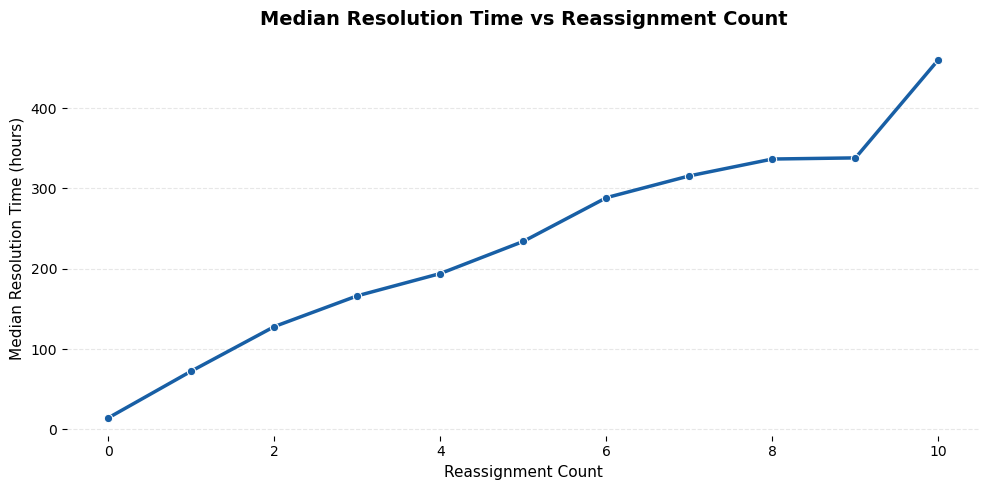

In [35]:
median_resolution = incident_df[incident_df["reassignment_count"] <= 10].groupby("reassignment_count")["resolution_time_hours"].median().reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(data=median_resolution, x="reassignment_count", y="resolution_time_hours", marker="o", color="#185FA5", linewidth=2.5, ax=ax)
ax.set_title("Median Resolution Time vs Reassignment Count", fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("Reassignment Count", fontsize=11)
ax.set_ylabel("Median Resolution Time (hours)", fontsize=11)
ax.yaxis.grid(True, linestyle="--", alpha=0.3)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

The line plot shows the median resolution time at each reassignment count level.

It can be clearly observed that as the reassignment count increases from 0 to 10, 
the median resolution time increases steadily. Incidents with 0 reassignments 
have a median resolution time of around 20 hours, while incidents that were 
reassigned 10 times have a median resolution time of around 450 hours.

This confirms a strong positive relationship between reassignment count and 
resolution time. The more times an incident is reassigned, the longer it takes 
to resolve. This makes reassignment_count one of the most important features 
for the prediction model.

## Feature Selection
The most relevant features for predicting resolution time are selected based 
on the findings from Stage 1 — Data Understanding and the visualisations 
in Stage 2.

In [36]:
features = [
    "priority",            # severity of the incident
    "impact",              # how many people are affected
    "urgency",             # how quickly it needs to be resolved
    "contact_type",        # how the incident was raised
    "category",            # type of incident
    "reassignment_count",  # number of times reassigned
    "reopen_count",        # number of times reopened
    "sys_mod_count",       # number of system modifications
    "made_sla"             # whether SLA was met
]
target = "resolution_time_hours"

model_df = incident_final[features + [target]].dropna()
print("Final dataset shape:", model_df.shape)
model_df.head()

Final dataset shape: (22168, 10)


,priority,impact,urgency,contact_type,category,reassignment_count,reopen_count,sys_mod_count,made_sla,resolution_time_hours
0,3 - Moderate,2 - Medium,2 - Medium,Phone,Category 55,0,0,4,True,10.216667
1,3 - Moderate,2 - Medium,2 - Medium,Phone,Category 40,1,0,8,True,29.200000
2,3 - Moderate,2 - Medium,2 - Medium,Phone,Category 20,0,0,6,True,20.750000
3,3 - Moderate,2 - Medium,2 - Medium,Phone,Category 9,0,0,3,True,53.466667
4,2 - High,1 - High,2 - Medium,Phone,Category 53,1,0,7,False,8.883333


Nine features were selected based on their relevance to resolution time prediction.

The features priority, impact, and urgency were selected because they directly 
affect how quickly an incident is handled.

The features reassignment_count, reopen_count, and sys_mod_count were selected 
because they measure the complexity of an incident. From the analysis it was 
observed that incidents with higher reassignment counts tend to take longer 
to resolve.

The features contact_type and category provide contextual information about 
how and why the incident was raised.

The feature made_sla was selected because it indicates whether the incident 
was resolved within the expected time limit, which is directly related to 
resolution time.

## Label Encoding
Categorical columns are converted to numbers so machine learning models can 
process them. Label Encoding assigns a unique integer to each category value.

In [38]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
cat_cols = ["priority", "impact", "urgency", "contact_type", "category"]

for col in cat_cols:
    model_df[col] = le.fit_transform(model_df[col].astype(str))

# converting boolean to integer
model_df["made_sla"] = model_df["made_sla"].astype(int)

print("Data types after encoding:")
print(model_df.dtypes)

Data types after encoding:
priority                   int32
impact                     int32
urgency                    int32
contact_type               int32
category                   int32
reassignment_count         int64
reopen_count               int64
sys_mod_count              int64
made_sla                   int32
resolution_time_hours    float64
dtype: object


All categorical columns have been encoded to numeric values using Label Encoding. 
Each unique category value has been assigned a number, for example priority 
values such as 3 - Moderate and 1 - Critical are converted to integers.

The made_sla boolean column has been converted from True and False to 1 and 0.

The dataset is now fully numeric and ready for modelling.

## Final Dataset Check Before Modelling

In [40]:
print("Final shape:    ", model_df.shape)
print("Missing values: ", model_df.isnull().sum().sum())
model_df.describe()

Final shape:     (22168, 10)
Missing values:  0


,priority,impact,urgency,contact_type,category,reassignment_count,reopen_count,sys_mod_count,made_sla,resolution_time_hours
count,22168.000000,22168.000000,22168.000000,22168.000000,22168.000000,22168.000000,22168.000000,22168.000000,22168.000000,22168.000000
mean,1.987279,1.008842,1.002256,2.003383,26.926922,0.853934,0.009699,4.619045,0.838235,85.873372
std,0.299502,0.210504,0.217215,0.098883,12.458225,1.348122,0.113372,3.849974,0.368243,138.579020
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.016667
25%,2.000000,1.000000,1.000000,2.000000,14.000000,0.000000,0.000000,2.000000,1.000000,0.366667
50%,2.000000,1.000000,1.000000,2.000000,28.000000,0.000000,0.000000,3.000000,1.000000,17.966667
75%,2.000000,1.000000,1.000000,2.000000,39.000000,1.000000,0.000000,6.000000,1.000000,120.850000
max,3.000000,2.000000,2.000000,3.000000,52.000000,20.000000,5.000000,82.000000,1.000000,719.866667


The final dataset was checked before moving to the modelling stage.

The dataset contains 22,168 incidents with 10 columns — 9 features and 1 target 
variable. No missing values remain in the dataset and all columns are fully numeric.

From the summary statistics it can be observed that:

The target variable resolution_time_hours has a mean of 85.87 hours and a median 
of 17.97 hours, confirming the right-skewed distribution seen earlier.

The reassignment_count has a mean of 0.85 and a maximum of 20, confirming that 
most incidents have low reassignment counts.

The made_sla column has a mean of 0.84, meaning approximately 84% of incidents 
in the final dataset met the SLA.

Data preparation is now complete. The dataset is clean, structured, and ready 
for Stage 3 — Modelling.